# 5-Year Survival Comparison: Logistic Regression vs Random Forest
Train the existing 5-year survival baseline and compare it with a Random Forest model on the same split.

## 1. Load Dataset and Inspect Schema
Load the processed survival CSV and review the columns, dtypes, and missing values.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parent
sys.path.insert(0, str(repo_root))

import json
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.config import PROCESSED_DATA_DIR, RESULTS_DIR

data_path = PROCESSED_DATA_DIR / "breast_cancer_survival_processed.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Missing CSV at {data_path}")

df = pd.read_csv(data_path)
print("Shape:", df.shape)
display(df.head())

print("Column dtypes:")
display(df.dtypes)

print("Missing values (top 10):")
display(df.isna().sum().sort_values(ascending=False).head(10))

Shape: (4023, 16)


,age,race,marital_status,t_stage,n_stage,sixth_stage,differentiation,grade,a_stage,tumor_size,estrogen_status,progesterone_status,regional_node_examined,regional_node_positive,survival_months,status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


Column dtypes:


age                       int64
race                        str
marital_status              str
t_stage                     str
n_stage                     str
sixth_stage                 str
differentiation             str
grade                     int64
a_stage                     str
tumor_size                int64
estrogen_status             str
progesterone_status         str
regional_node_examined    int64
regional_node_positive    int64
survival_months           int64
status                      str
dtype: object

Missing values (top 10):


age                0
race               0
marital_status     0
t_stage            0
n_stage            0
sixth_stage        0
differentiation    0
grade              0
a_stage            0
tumor_size         0
dtype: int64

## 2. Create the 5-Year Target
Define the label as 1 when `survival_months >= 60`, otherwise 0.

In [2]:
df["survived_5yr"] = (df["survival_months"] >= 60).astype(int)

print("5-year label balance:")
display(df["survived_5yr"].value_counts().rename("count"))
display(df["survived_5yr"].value_counts(normalize=True).rename("ratio"))

5-year label balance:


survived_5yr
1    2821
0    1202
Name: count, dtype: int64

survived_5yr
1    0.701218
0    0.298782
Name: ratio, dtype: float64

## 3. Prepare Features and Split
Remove leakage columns, encode categoricals, scale numeric features, and split the data once so both models are comparable.

In [4]:
target = "survived_5yr"
leakage_cols = ["survival_months", "status"]
feature_cols = [col for col in df.columns if col not in leakage_cols + [target]]

X = df[feature_cols]
y = df[target]

categorical_cols = X.select_dtypes(include=["object", "str"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

try:
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", categorical_encoder, categorical_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("Train balance:")
display(y_train.value_counts(normalize=True).sort_index().rename("ratio"))
print("Test balance:")
display(y_test.value_counts(normalize=True).sort_index().rename("ratio"))

Train shape: (3218, 14) (3218,)
Test shape: (805, 14) (805,)
Train balance:


survived_5yr
0    0.298633
1    0.701367
Name: ratio, dtype: float64

Test balance:


survived_5yr
0    0.299379
1    0.700621
Name: ratio, dtype: float64

## 4. Train the Baseline Model
Use the same logistic regression baseline as the existing notebook so the comparison stays consistent.

In [5]:
baseline_model = LogisticRegression(max_iter=1000, class_weight="balanced")
baseline_clf = Pipeline(steps=[("preprocessor", preprocessor), ("model", baseline_model)])
baseline_clf.fit(X_train, y_train)

baseline_proba = baseline_clf.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_proba >= 0.5).astype(int)

print("Baseline logistic regression report:")
print(classification_report(y_test, baseline_pred, digits=3, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, baseline_pred))

Baseline logistic regression report:
              precision    recall  f1-score   support

           0      0.327     0.423     0.369       241
           1      0.718     0.628     0.670       564

    accuracy                          0.566       805
   macro avg      0.522     0.525     0.519       805
weighted avg      0.601     0.566     0.580       805

Confusion matrix:
[[102 139]
 [210 354]]


## 5. Train the Random Forest Model
Fit a Random Forest on the same feature split and evaluate it with the same threshold.

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_clf = Pipeline(steps=[("preprocessor", preprocessor), ("model", rf_model)])
rf_clf.fit(X_train, y_train)

rf_proba = rf_clf.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= 0.5).astype(int)

print("Random Forest report:")
print(classification_report(y_test, rf_pred, digits=3, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest report:
              precision    recall  f1-score   support

           0      0.402     0.137     0.204       241
           1      0.712     0.913     0.800       564

    accuracy                          0.681       805
   macro avg      0.557     0.525     0.502       805
weighted avg      0.620     0.681     0.622       805

Confusion matrix:
[[ 33 208]
 [ 49 515]]


## 6. Compare the Results
Compare accuracy, precision, recall, F1, and ROC AUC for both models in one table.

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.680745,0.712310,0.913121,0.800311,0.543090
1,Logistic Regression,0.566460,0.718053,0.627660,0.669820,0.542149


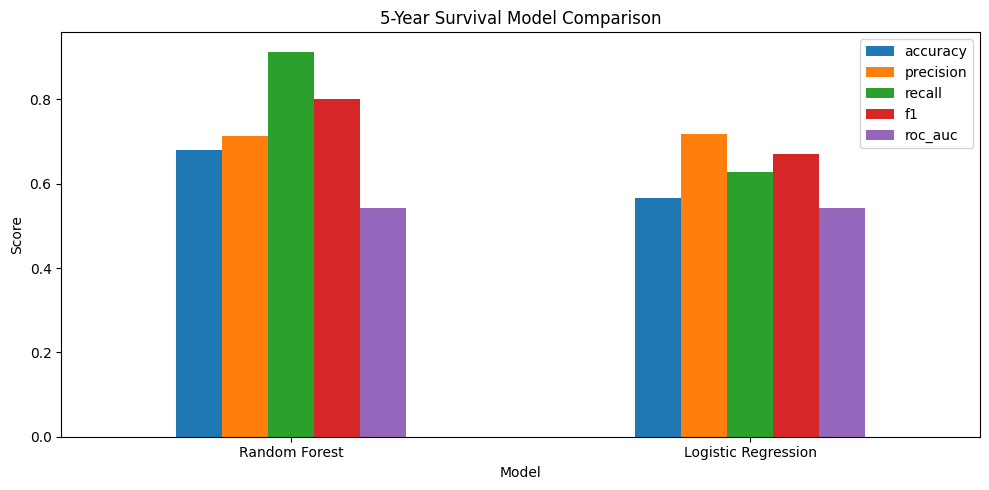

In [7]:
def summarize_model(model_name, y_true, y_pred, y_proba):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

comparison_df = pd.DataFrame([
    summarize_model("Logistic Regression", y_test, baseline_pred, baseline_proba),
    summarize_model("Random Forest", y_test, rf_pred, rf_proba),
]).sort_values("f1", ascending=False).reset_index(drop=True)

display(comparison_df)

ax = comparison_df.set_index("model")[ ["accuracy", "precision", "recall", "f1", "roc_auc"] ].plot(
    kind="bar",
    figsize=(10, 5),
    rot=0,
    title="5-Year Survival Model Comparison",
)
ax.set_xlabel("Model")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

## 7. Save Artifacts and Random Forest Feature Importance
Persist both pipelines, the comparison table, and the Random Forest feature importances for later reuse.

,feature,importance
0,num__age,0.227180
3,num__regional_node_examined,0.218019
2,num__tumor_size,0.197573
4,num__regional_node_positive,0.095557
9,cat__marital_status_Married,0.021552
1,num__grade,0.018438
11,cat__marital_status_Single,0.016999
8,cat__marital_status_Divorced,0.015092
7,cat__race_White,0.014374
25,cat__differentiation_Moderately differentiated,0.013995


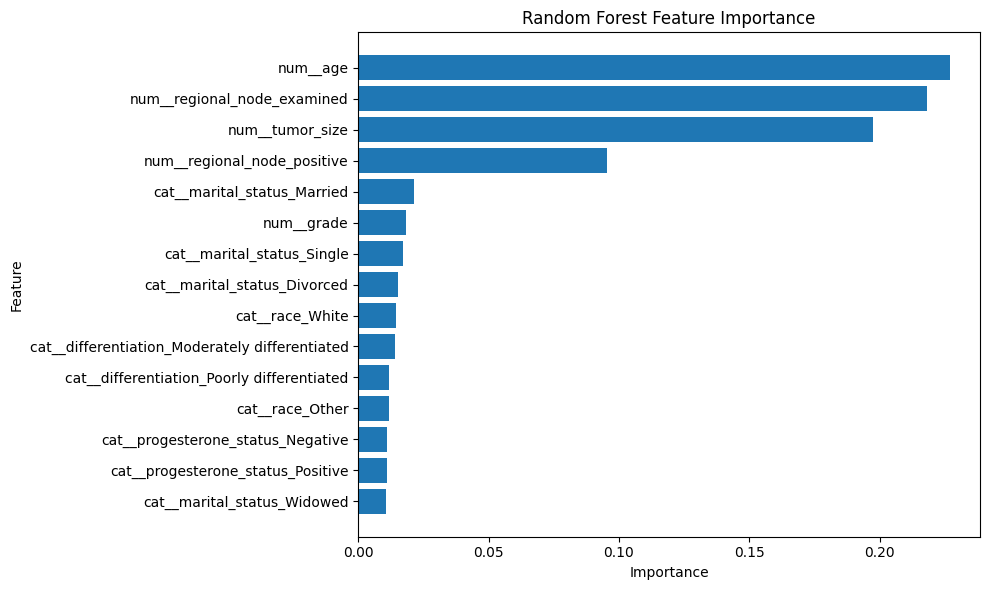

Saved artifacts to: E:\MIU\ML\Projects\ml-project\results\survival_5yr_rf_20260606_205531


In [8]:
run_id = datetime.now().strftime("survival_5yr_rf_%Y%m%d_%H%M%S")
run_dir = RESULTS_DIR / run_id
run_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(baseline_clf, run_dir / "survival_5yr_logistic_pipeline.joblib")
joblib.dump(rf_clf, run_dir / "survival_5yr_random_forest_pipeline.joblib")
comparison_df.to_csv(run_dir / "model_comparison.csv", index=False)

metrics = {
    row["model"]: {
        "accuracy": float(row["accuracy"]),
        "precision": float(row["precision"]),
        "recall": float(row["recall"]),
        "f1": float(row["f1"]),
        "roc_auc": float(row["roc_auc"]),
    }
    for _, row in comparison_df.iterrows()
}
(run_dir / "metrics.json").write_text(json.dumps(metrics, indent=2))

feature_names = rf_clf.named_steps["preprocessor"].get_feature_names_out()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_clf.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)
importance_df.to_csv(run_dir / "random_forest_feature_importance.csv", index=False)

display(importance_df.head(15))

top_features = importance_df.head(15).iloc[::-1]
plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

print("Saved artifacts to:", run_dir)